# Auto encoders

## building denoising autoencoder (mnist)

### load pre-process and add noise to dataset

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
import tensorflow
from tensorflow.keras.datasets import mnist

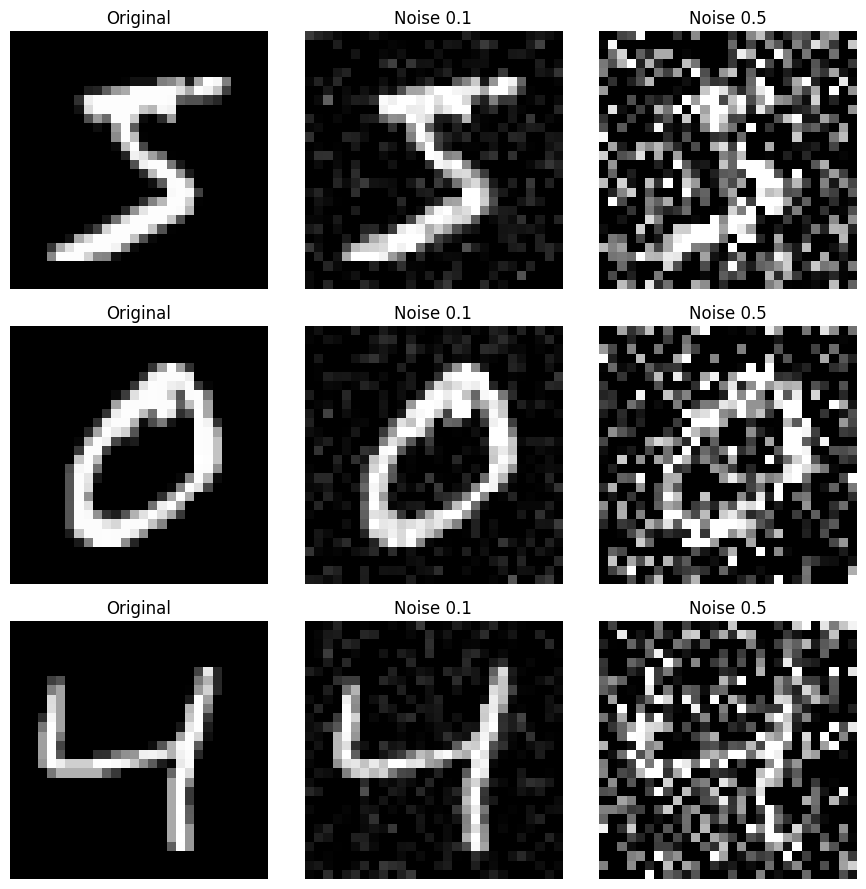

In [3]:
from tensorflow.keras import layers


# load the dataset
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

#generate noisy versions
noise_factor_low = 0.1
noise_factor_high = 0.5

x_train_noisy_low = x_train + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train.
shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train
.shape)
x_test_noisy_low = x_test + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_test.
shape)
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_test.
shape)

# clip pixel values to [0, 1]
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)

#visualize in a 3 x 3 grid
n = 3 # number of images to show

plt.figure(figsize=(9, 9))
for i in range(n):
    # original image
    ax = plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")
    # low noise image
    ax = plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap="gray")
    plt.title("Noise 0.1")
    plt.axis("off")
    # high noise image
    ax = plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap="gray")
    plt.title("Noise 0.5")
    plt.axis("off")

plt.tight_layout()
plt.show()

### build an encoder

In [4]:
from tensorflow.keras import layers

def build_encoder(input_shape=(28, 28, 1)):
    """ 
    Builds the encoder  part of convolutional autoencoder.

    Parameters:
        input_shape (tuple): Shape of input image. Defaults to (28, 28, 1)  for MNIST

    Returns: 
        input_img (Keras Input): Input layer of the model
        encoded (Keras Tensor) : Encoded representation after convolution and pooling
    """
    input_img = layers.Input(shape=input_shape, name="input")
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2), padding="same")(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding="same", name="encoded")(x)
    return input_img, encoded 

### build a decoder 

In [5]:
def build_decoder(encoded_input):
    """ 
    Builds the decoder  part of convolutional autoencoder.

    Parameters:
        encoded_input (keras Tensor): The output from the encoder

    Returns: 
        decoded (Keras Tensor) : The reconstructed output after upsampling
    """
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='decoded')(x)
    return decoded

### build autoencoder

In [6]:
import numpy as np
import tensorflow as tf

print(np.__version__)
print(tf.config.list_physical_devices('GPU'))

1.26.4
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
def build_autoencoder():
    """
    Constructs and compiles the full convolutional autoencoder by connecting the encoder and decoder part 

    Returns: 
        autoencoder(Keras Model): Compiled autoencoder model
    """
    input_img, encoded_output = build_encoder()
    decoded_output = build_decoder(encoded_input=encoded_output)
    autoencoder = keras.Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
    autoencoder.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return autoencoder

### compile the model

In [8]:
autoencoder = build_autoencoder();
autoencoder.summary()

I0000 00:00:1777629980.200718   24747 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1205 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

## train the autoencoder

In [9]:
history = autoencoder.fit(
    x_train_noisy_high, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_high, x_test),
    verbose=1
)

Epoch 1/10


I0000 00:00:1777629983.184526   24872 service.cc:153] XLA service 0x7f21b00054e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777629983.184775   24872 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1777629983.210675   24872 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777629983.394035   24872 cuda_dnn.cc:461] Loaded cuDNN version 92101


 19/469 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7774 - loss: 0.5536

I0000 00:00:1777629988.617668   24872 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.8077 - loss: 0.1515 - val_accuracy: 0.8097 - val_loss: 0.1124
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8117 - loss: 0.1092 - val_accuracy: 0.8109 - val_loss: 0.1047
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8125 - loss: 0.1039 - val_accuracy: 0.8120 - val_loss: 0.1014
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8128 - loss: 0.1015 - val_accuracy: 0.8124 - val_loss: 0.1001
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8130 - loss: 0.0998 - val_accuracy: 0.8120 - val_loss: 0.0985
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8131 - loss: 0.0987 - val_accuracy: 0.8124 - val_loss: 0.0976
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8133 - loss: 0.0978 - val_accuracy: 0.8122 - val_loss: 0.0967
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8133 - loss: 0.0971 - val_accuracy: 0.8123

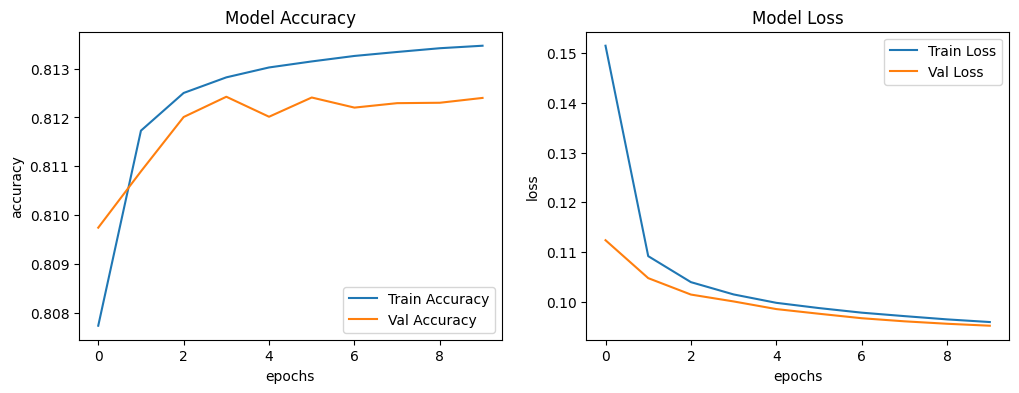

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Model Accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Model Loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()

## Evaluate encoder

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


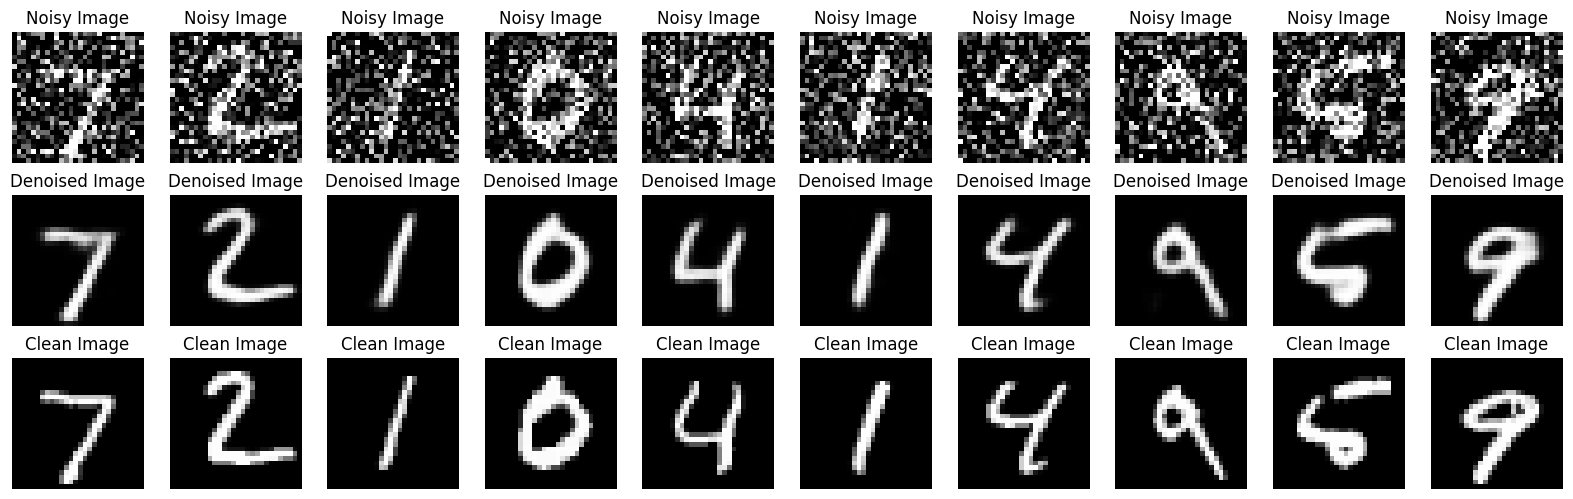

In [11]:
# Predict the denoised images from noisy test images
denoised_images = autoencoder.predict(x_test_noisy_high)

# Function to display images
def plot_images(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))
    for i in range(n):
      # Plot noisy images
      plt.subplot(3, n, i + 1)
      plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
      plt.title("Noisy Image")
      plt.axis('off')

      # Plot denoised images
      plt.subplot(3, n, i + 1 + n)
      plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
      plt.title("Denoised Image")
      plt.axis('off')

      # Plot clean images
      plt.subplot(3, n, i + 1 + 2 * n)
      plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
      plt.title("Clean Image")
      plt.axis('off')
    plt.show()

# Display the first 10 images
plot_images(x_test_noisy_high, denoised_images, x_test, n=10)